In [5]:
import matplotlib.pyplot as plt
import numpy as np

g = 10

def Solve(Tf, dt):
    t = np.arange(0, Tf+dt, dt)
    Nt = len(t)
    
    theta = np.zeros((2, Nt))
    p = np.zeros((2, Nt))
    
    k1theta = np.zeros(2)
    k2theta = np.zeros(2)
    k1p = np.zeros(2)
    k2p = np.zeros(2)
    
    M = np.array([m1, m2])
    L = np.array([l1, l2])
    
    theta[0][0] = theta10
    theta[1][0] = theta20
    
    p[0][0] = p10
    p[1][0] = p20
    
    for i in range(Nt-1):
        for j in range(2):
            for k in range(2):
                if j != k:
                    k1p[j] = (-M[j]*g*L[j]*np.sin(theta[j][i]) - p[j][i]*p[k][i]*np.sin(theta[j][i] - theta[k][i])/(m1*l1*l2))*dt
        
                    k1theta[j] = ((p[j][i])/(M[j]*(L[j]**2)) - p[k][i]*np.cos(theta[j][i] - theta[k][i])/(m1*l1*l2))*dt
                    
        for j in range(2):
            for k in range(2):
                if j != k:
                    k2p[j] = (-M[j]*g*L[j]*np.sin(theta[j][i]+k1theta[j]/2) - (p[j][i]+k1p[j]/2)*(p[k][i]+k1p[k]/2)*np.sin(theta[j][i] + k1theta[j]/2 -k1theta[k]/2 - theta[k][i])/(m1*l1*l2))*dt
        
                    k2theta[j] = (((p[j][i]+k1p[j]/2))/(M[j]*(L[j]**2)) - (p[k][i]+k1p[k]/2)*np.cos(theta[j][i]+k1theta[j]/2 - k1theta[k]/2 - theta[k][i])/(m1*l1*l2))*dt
                    
        for j in range(2):
            theta[j][i+1] = theta[j][i] + k2theta[j]
            p[j][i+1] = p[j][i] + k2p[j]
            
            if theta[j][i+1] > np.pi:
                theta[j][i+1] += -2*np.pi
            elif theta[j][i+1] < -np.pi:
                theta[j][i+1] += 2*np.pi
            
    return t, theta, p



In [15]:
E = 0.1 #Joules
m1= 0.1 # in kg
m2= 0.005 # in kg
l1= 0.5 # in m
l2= 0.5 # in m

theta10= 0. # in rad
theta20= np.pi/2 # in rad
p20=0. # in kg m^2/s

#Das notas de aula,
#p1 = np.sqrt(2*m1*l1^2*(E- m2*g*l2))
p10= np.sqrt(2*m1*l1**2*(E - m2*g*l2)) # in kg m^2/s

print(f"p10 = {p10:.6f} kg m^2/s")

#Calculamos tempo da simulacao com base no periodo do pendulo simples  para m1
T0 = 2*np.pi*np.sqrt(l1/g) # in s

dt= 2e-4 # in s
Tf= 5*T0 # in s

t, theta, p = Solve(Tf, dt)

Nt = len(t)


p10 = 0.061237 kg m^2/s


Maximo local em t = 0.372000 s, theta_1 = 0.585717 rad
Maximo local em t = 1.788800 s, theta_1 = 0.612703 rad
Maximo local em t = 3.235400 s, theta_1 = 0.510221 rad
Maximo local em t = 4.665800 s, theta_1 = 0.534029 rad
Maximo local em t = 6.071800 s, theta_1 = 0.642960 rad
Period = 1.416800 s
Period = 1.446600 s
Period = 1.430400 s
Period = 1.406000 s


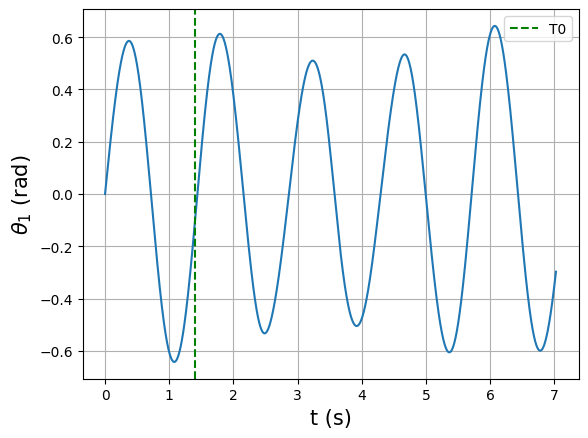

In [29]:
#Checa se um elemento eh maior que seus vizinhos
is_maxima = (theta[0, 1:-1] > theta[0, :-2]) & (theta[0, 1:-1] > theta[0, 2:])

#Ajusta indices porque nos fatiamos fora o primeiro e ultimo elementos 
indices = np.where(is_maxima)[0] + 1

for i in indices:
    print(f"Maximo local em t = {t[i]:.6f} s, theta_1 = {theta[0][i]:.6f} rad")

for i in range(1, len(indices)):

    print(f"Period = {t[indices[i]]-t[indices[i-1]]:.6f} s")

plt.plot(t, theta[0])
plt.axvline(T0, color='green', linestyle='--', label = 'T0')
plt.xlabel('t (s)', fontsize = 15)
plt.ylabel(r'$\theta_1$ (rad)', fontsize = 15)

plt.grid(True) 
plt.legend()